In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e8/sample_submission.csv
/kaggle/input/playground-series-s5e8/train.csv
/kaggle/input/playground-series-s5e8/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/playground-series-s5e8/train.csv")
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Check for missing values explicitly
print(train.isnull().sum())

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


y
0    659512
1     90488
Name: count, dtype: int64
y
0    0.879349
1    0.120651
Name: proportion, dtype: float64


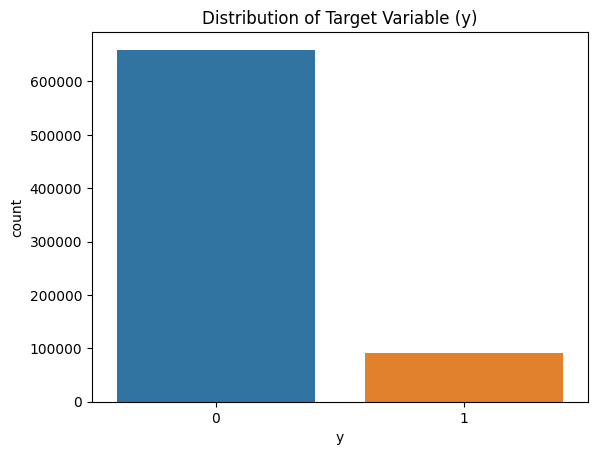

In [6]:
# Check the distribution of the target variable 'y'
print(train['y'].value_counts())
print(train['y'].value_counts(normalize=True)) # Shows percentage

# Plot the target variable
sns.countplot(x='y', data=train)
plt.title('Distribution of Target Variable (y)')
plt.show()

In [7]:
train.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,216506.495284,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,0.000000,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,187499.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,374999.500000,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,562499.250000,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,749999.000000,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [8]:
train.describe().columns

Index(['id', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays',
       'previous', 'y'],
      dtype='object')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

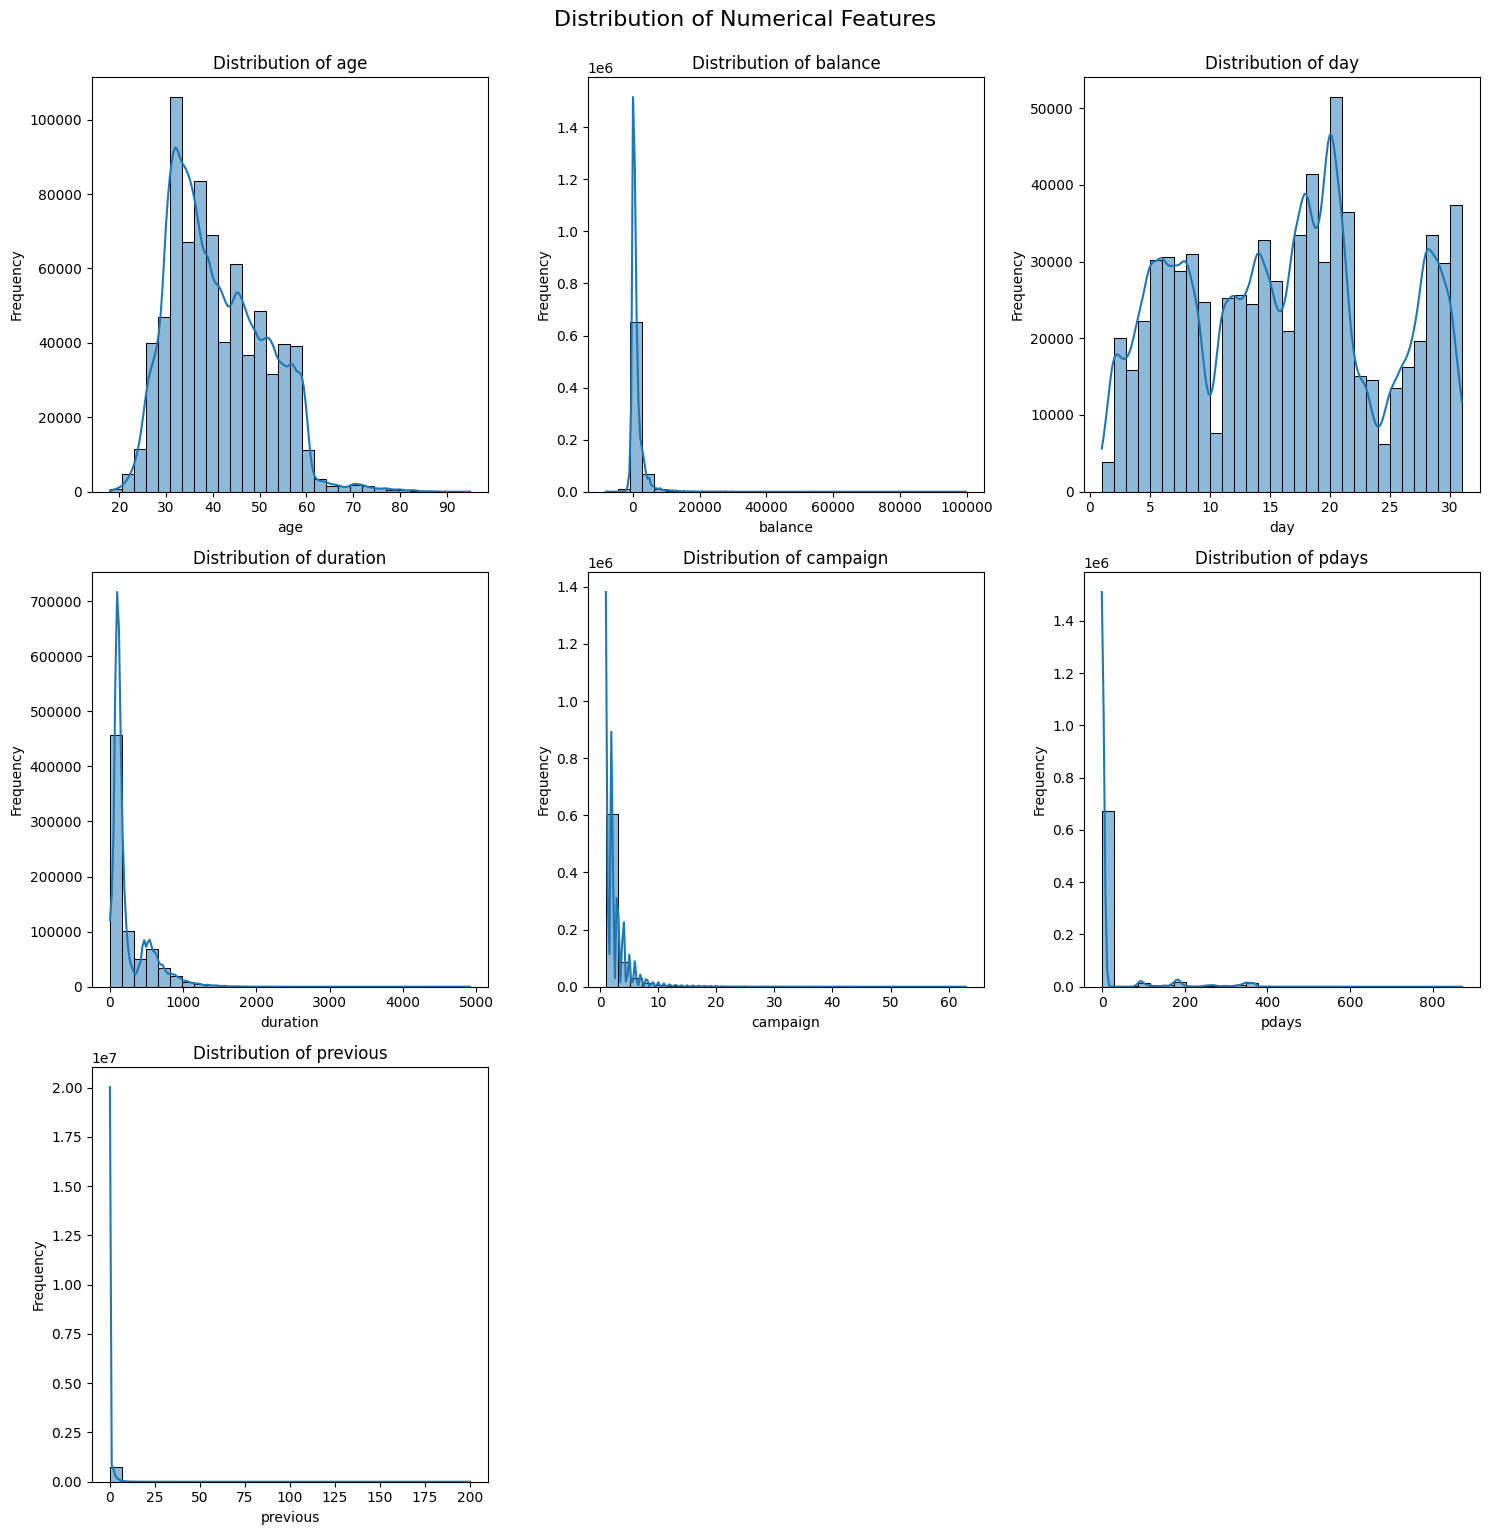

In [9]:
numerical_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Calculate the grid size dynamically
n_features = len(numerical_features)
n_cols = 3  # You can adjust this
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division

# Create subplots with the correct grid size
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.ravel()  # Flatten the array

for i, feature in enumerate(numerical_features):
    sns.histplot(train[feature], bins=30, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for i in range(n_features, n_rows * n_cols):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle('Distribution of Numerical Features', y=1.02, fontsize=16)
plt.show()

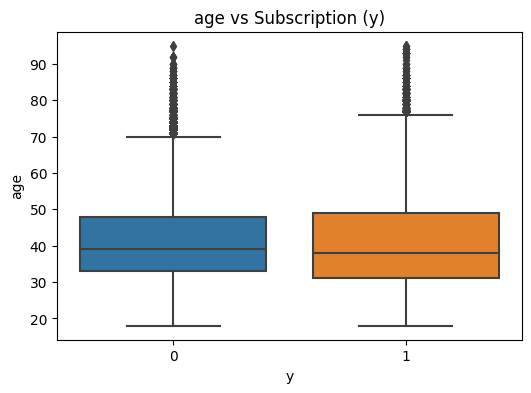

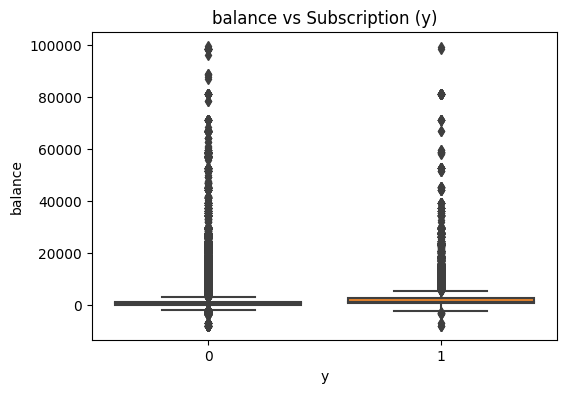

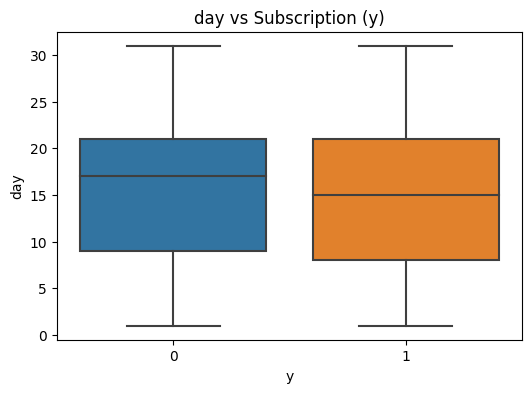

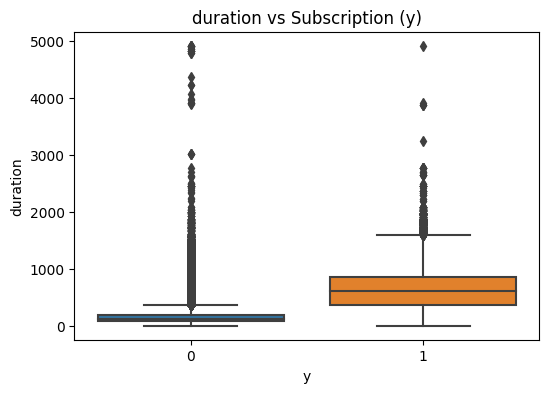

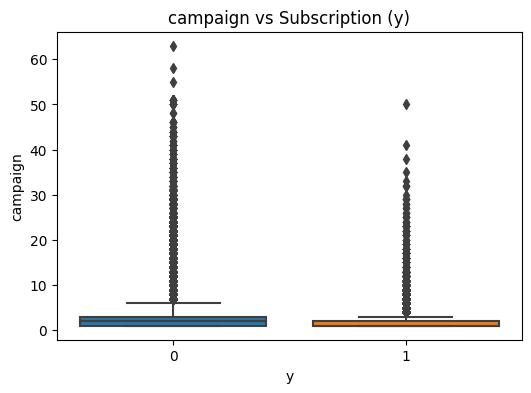

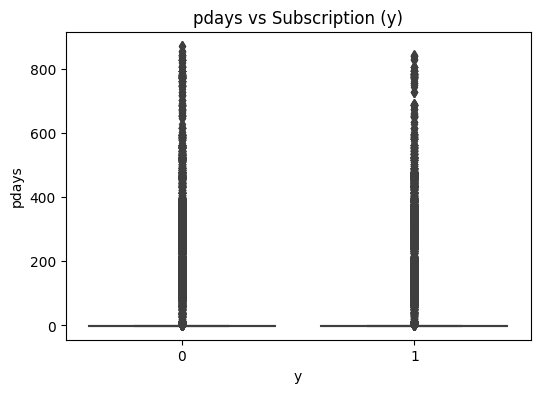

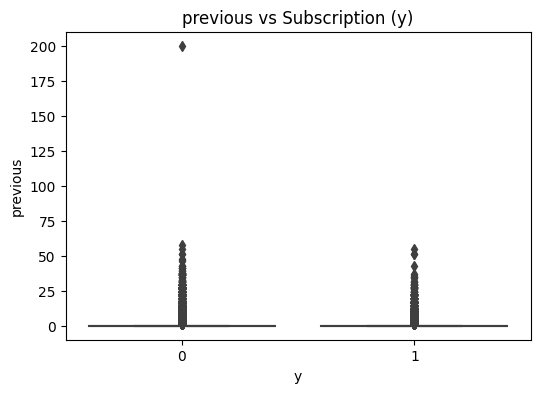

In [10]:
# Create boxplots to see relationship with target
for feature in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='y', y=feature, data=train)
    plt.title(f'{feature} vs Subscription (y)')
    plt.show()

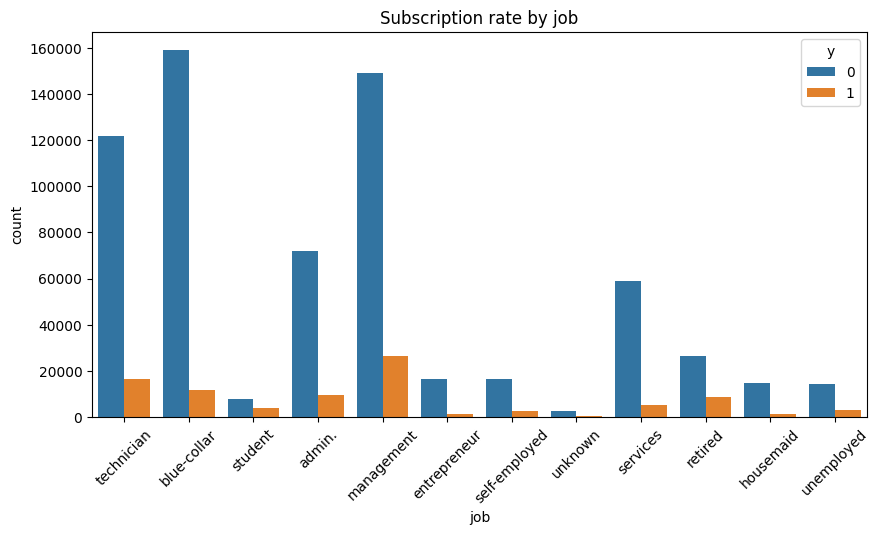

y                      0          1
job                                
admin.         88.354685  11.645315
blue-collar    93.256226   6.743774
entrepreneur   91.861384   8.138616
housemaid      91.534691   8.465309
management     84.960778  15.039222
retired        75.375870  24.624130
self-employed  87.055731  12.944269
services       91.728574   8.271426
student        65.921645  34.078355
technician     88.167870  11.832130
unemployed     82.017693  17.982307
unknown        87.932808  12.067192


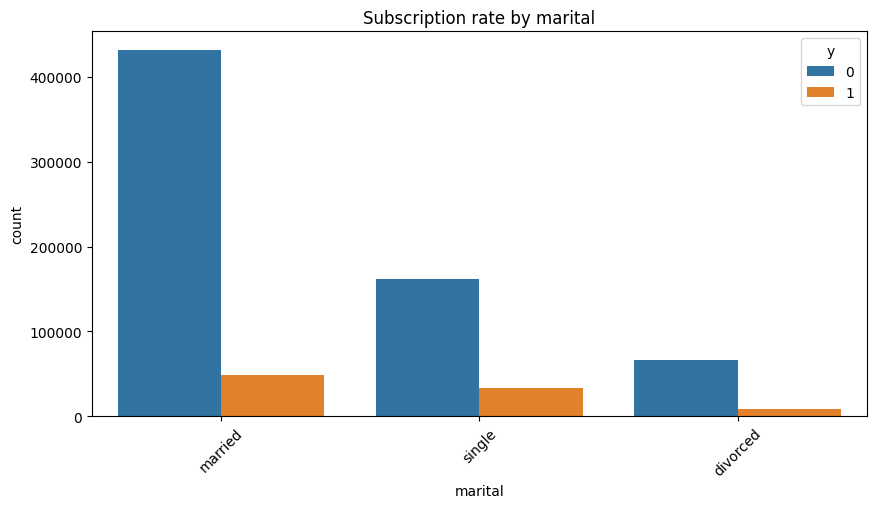

y                 0          1
marital                       
divorced  88.842448  11.157552
married   89.812775  10.187225
single    82.954720  17.045280


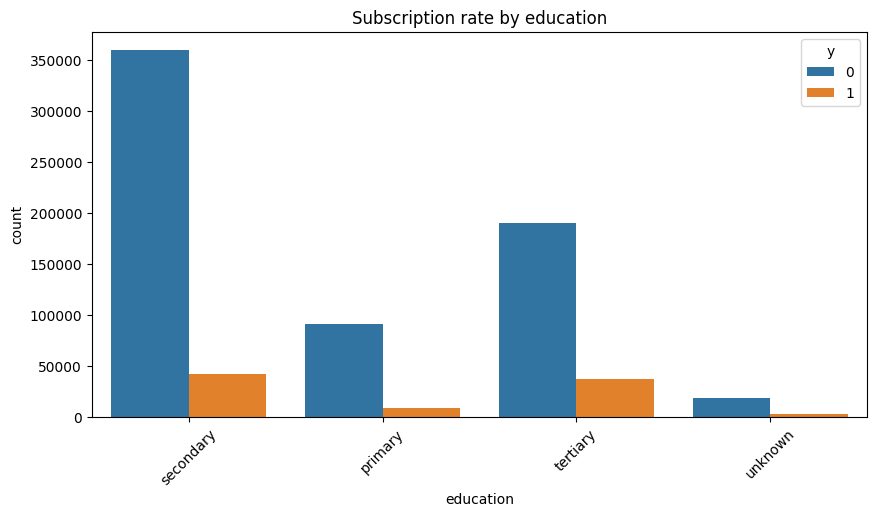

y                  0          1
education                      
primary    91.690282   8.309718
secondary  89.450885  10.549115
tertiary   83.735077  16.264923
unknown    86.661346  13.338654


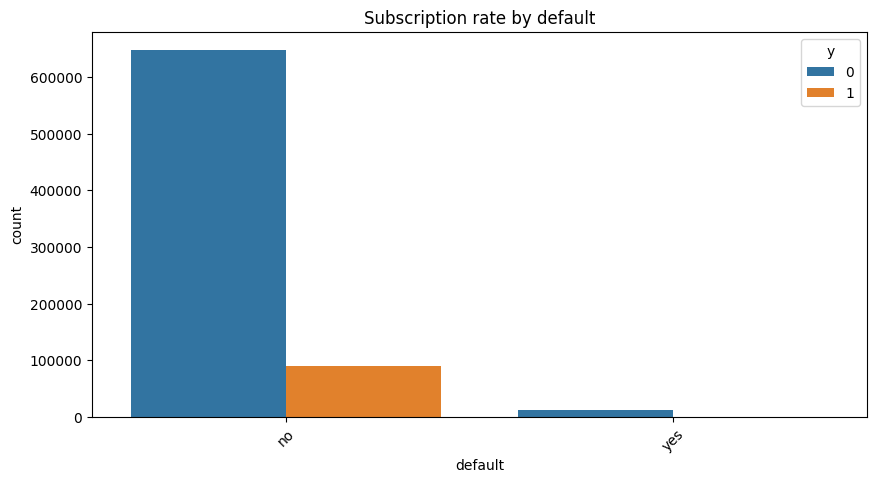

y                0          1
default                      
no       87.805348  12.194652
yes      95.369289   4.630711


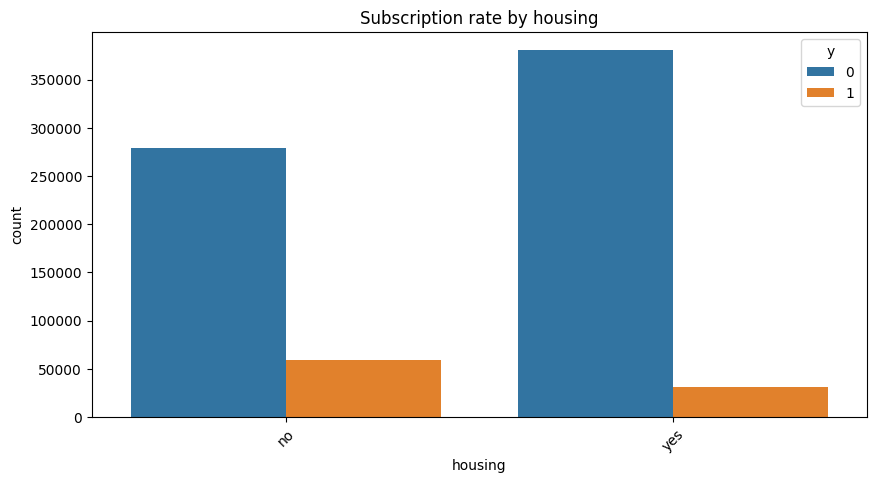

y                0          1
housing                      
no       82.422235  17.577765
yes      92.474859   7.525141


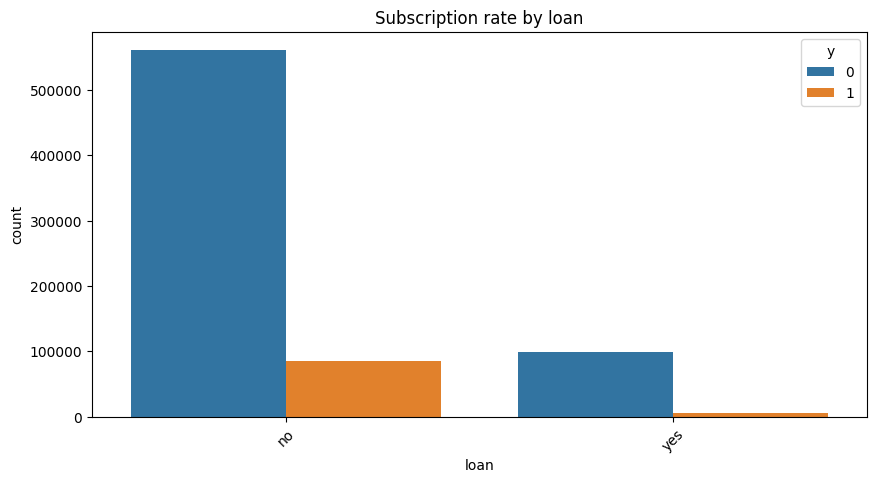

y             0          1
loan                      
no    86.862174  13.137826
yes   94.526420   5.473580


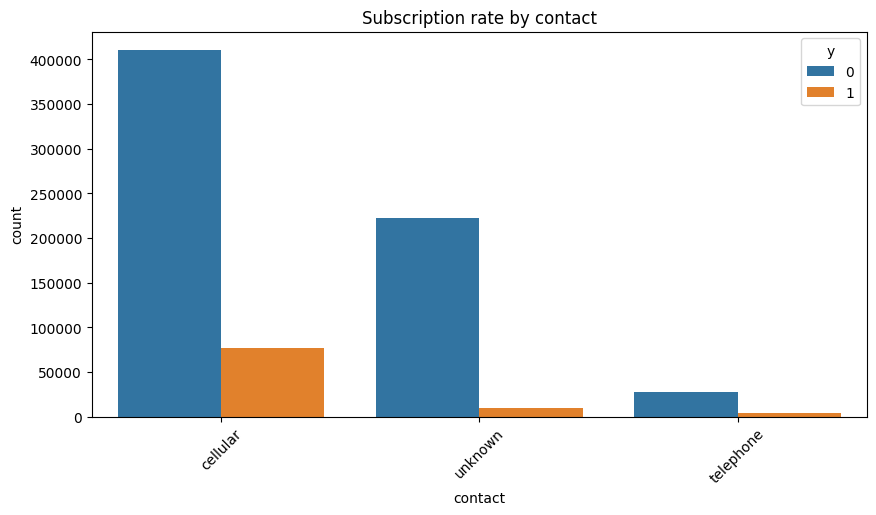

y                  0          1
contact                        
cellular   84.342090  15.657910
telephone  86.320071  13.679929
unknown    95.704732   4.295268


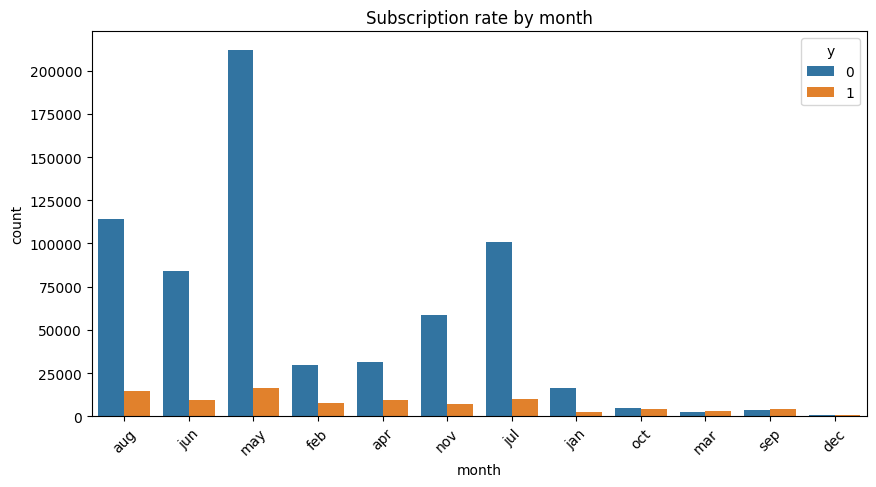

y              0          1
month                      
apr    76.434570  23.565430
aug    88.783865  11.216135
dec    48.670855  51.329145
feb    79.319880  20.680120
jan    87.585151  12.414849
jul    90.915253   9.084747
jun    89.627415  10.372585
mar    42.864529  57.135471
may    92.864617   7.135383
nov    89.019406  10.980594
oct    50.999565  49.000435
sep    46.524497  53.475503


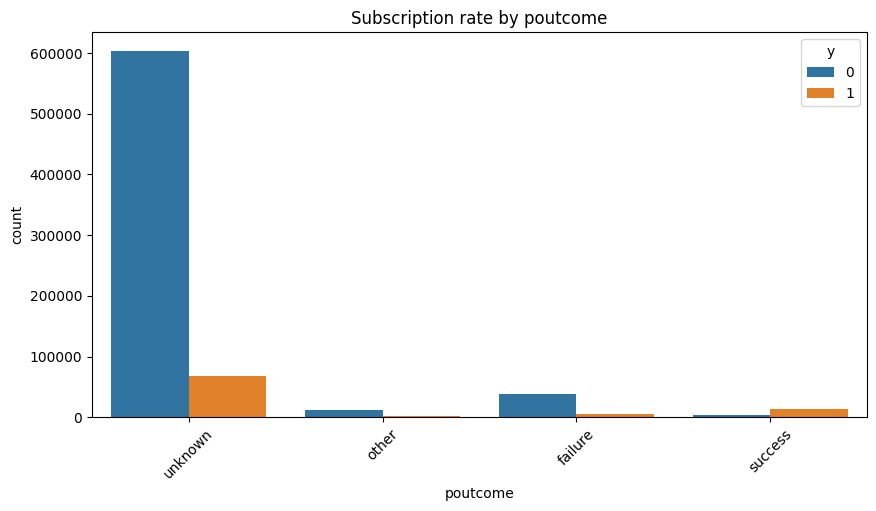

y                 0          1
poutcome                      
failure   86.720603  13.279397
other     83.315247  16.684753
success   23.599570  76.400430
unknown   89.810246  10.189754


In [11]:
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

for feature in categorical_features:
    plt.figure(figsize=(10,5))
    # Plot count of each category, colored by the target 'y'
    sns.countplot(x=feature, hue='y', data=train)
    plt.title(f'Subscription rate by {feature}')
    plt.xticks(rotation=45)
    plt.show()

    # You can also calculate the percentage of subscriptions per category
    print(pd.crosstab(train[feature], train['y'], normalize='index') * 100)

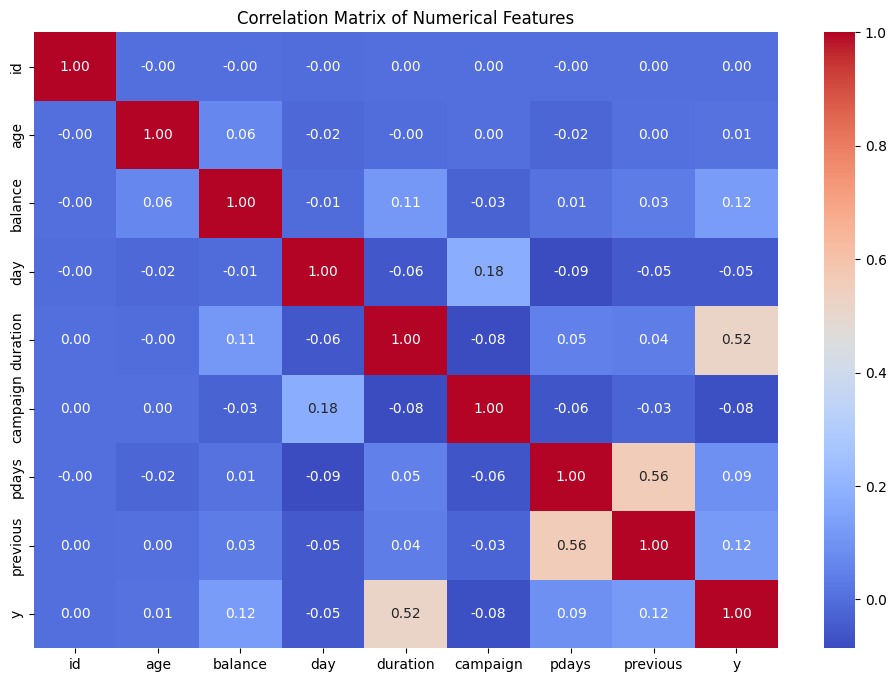

In [12]:
# Compute the correlation matrix
corr_matrix = train.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [13]:
def handle_unknown(df = pd.DataFrame):

    # For this strategy, we will only turn unknown values into the most frequent value that appears
    df = df.copy()
    to_change = ['job', 'education', 'contact']
    for col in to_change:
        df[col] = df[col].replace('unknown', df[df[col] != 'unknown'][col].mode()[0])
    return df

In [14]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = train.drop(columns=['id', 'y'], axis=1)
y = train['y']

# Split the data into training and testing sets (e.g., 80%/20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
!pip install --upgrade scikit-learn==1.2.2 imbalanced-learn==0.10.1 --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 7.8 MB/s eta 0:00:00


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, FunctionTransformer, OrdinalEncoder, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

to_ohe = ['job','marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
to_ord = ['education']
numerical_features = ['age', 'balance', 'day', 'pdays', 'previous']
# We can probably robust scale everything

In [17]:
handle_unknown_fct = FunctionTransformer(handle_unknown)

preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), to_ohe),
        ('ord', OrdinalEncoder(), to_ord)
    ],
    remainder='passthrough'
)

# Wrap with full pipeline (including your unknown handler first)
pre_process_pipeline = Pipeline(steps=[
    ('handle_unknown', handle_unknown_fct),   # custom transformer
    ('preprocess', preprocess_pipeline)
])

In [18]:
# Define the models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42) # Note: GB doesn't have class_weight, so use SMOTE
}

# Train and evaluate each model
for name, model in models.items():
    # Create a pipeline: Preprocessor -> Model
    pipeline = Pipeline(steps=[('preprocessor', pre_process_pipeline),
                              ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    # Print evaluation metrics
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.98      0.86      0.92    131902
           1       0.47      0.87      0.61     18098

    accuracy                           0.87    150000
   macro avg       0.72      0.87      0.76    150000
weighted avg       0.92      0.87      0.88    150000

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    131902
           1       0.75      0.60      0.67     18098

    accuracy                           0.93    150000
   macro avg       0.85      0.79      0.81    150000
weighted avg       0.92      0.93      0.92    150000

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.96    131902
           1       0.74      0.56      0.64     18098

    accuracy                           0.92    150000
   macro avg       0.84      0.77      0.80    15000

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.98      0.86      0.92    131902
           1       0.47      0.87      0.61     18098

    accuracy                           0.87    150000
   macro avg       0.72      0.87      0.76    150000
weighted avg       0.92      0.87      0.88    150000

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    131902
           1       0.75      0.60      0.67     18098

    accuracy                           0.93    150000
   macro avg       0.85      0.79      0.81    150000
weighted avg       0.92      0.93      0.92    150000

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.96    131902
           1       0.74      0.56      0.64     18098

    accuracy                           0.92    150000
   macro avg       0.84      0.77      0.80    150000
weighted avg       0.92      0.92      0.92    150000

In [19]:
test = pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv')
test

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,999995,43,management,married,tertiary,no,0,yes,no,cellular,18,nov,65,2,-1,0,unknown
249996,999996,40,services,married,unknown,no,522,yes,no,cellular,19,nov,531,1,189,1,failure
249997,999997,63,retired,married,primary,no,33,no,no,cellular,3,jul,178,1,92,8,success
249998,999998,50,blue-collar,married,primary,no,2629,yes,no,unknown,30,may,163,2,-1,0,unknown


In [20]:
pipeline_sub = Pipeline(steps=[('preprocessor', pre_process_pipeline),
                            ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200))])
pipeline.fit(X_train, y_train)
test_ready = test.drop(columns='id')
y_pred_sub = pipeline.predict_proba(test_ready)

In [21]:
y_pred_sub[:,1]

array([0.06620021, 0.16208884, 0.00468764, ..., 0.79765254, 0.01093719,
       0.0267853 ])

In [22]:
submission = pd.DataFrame({'id': test['id'], 'y': y_pred_sub[:,1]})
submission.to_csv('/kaggle/working/submission.csv', index=False)

In [23]:
# print(classification_report(y_test, y_pred))
# print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba)) # Use predicted probabilities
# sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
# plt.title('Confusion Matrix')
#plt.show()

In [24]:
#from imblearn.over_sampling import SMOTE
#smote = SMOTE(random_state=42)
#X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# For Gradient bossting